# Regime Classification (Step 3)

**Stats-based behavioral clustering** — each county gets one behavioral identity from a
significance-gated rule tree on the source-coverage-masked ≥8h annual series. A **router / identity**
(behavior, not cause — A013), **not** a forecast. Model selection / backtesting is **Step 5**.

**Overview (share this):** [`README.md`](../../docs/methodology/03_risk_clustering/README.md) · **Canonical method:** [`regime_classification_methodology.md`](../../docs/methodology/03_risk_clustering/regime_classification_methodology.md) · **Assumptions:** A013 · A014 · A015 · A016.

```
 outcomes   stable · trend · shift · episodic        +  INSUFFICIENT (we can't confidently type it)
 the reframe: ABSTAIN, don't force — for thin / recently-changed / near-zero counties the logic isn't
              wrong, the DATA can't support a label. ~11% land in insufficient, with a reason.
 decision   gates(insufficient) → episodic → step(shift | recent-change) → trend → stable
```

In [1]:
import numpy as np, pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

CATALOG, T_MAIN, T_GRID, MIN_OBS = "eagle-i-45min", 8, [2, 4, 8, 12, 24], 5
VOL_GATE, REVERT_FRAC, SENT = 15, 0.60, 1e9
TREND_T, EP_PEAK, EP_TOP2, EP_DEPEAK_T = 2.5, 0.40, 0.60, 2.0
R_STEP_MIN, STEP_OVER_LINE, SHIFT_JUMP_Z = 0.55, 0.10, 2.0
TIGHT_CV, VOL_CONF, HI_OBS, HI_MAX_START = 0.15, 20, 8, 2016
STRUCT = {"trend", "shift", "episodic"}   # the "structured" labels (vs stable/insufficient)

TREND_P = f"../../curated_outage_data/outputs/county_trend/county_yearly_trend__{CATALOG}.parquet"
MASK_P  = "../outputs/source_coverage_mask/county_year_coverage_mask.csv"

## 1. Input — the masked ≥8h annual series

Observed years only (coverage-ramp years nulled). **A016 caveat:** the mask is all-duration-derived,
applied to the ≥8h series — flagged, not silent.

In [2]:
mask = pd.read_csv(MASK_P)
observed = {(int(r.fips), int(r.year)): bool(r.observed) for r in mask.itertuples()}
names    = {int(r.fips): (r.county, r.state) for r in mask.itertuples()}
trend    = pd.read_parquet(TREND_P)

def load_series(T):
    d = trend[trend['T'] == T][['fips', 'years', 'yearly_counts']]; s = {}
    for r in d.itertuples():
        fips, pairs = int(r.fips), []
        for y, c in zip(r.years, r.yearly_counts):
            y = int(y)
            if c is None or (isinstance(c, float) and np.isnan(c)): continue
            if observed.get((fips, y), False): pairs.append((y, float(c)))
        pairs.sort(); s[fips] = pairs
    return s

s8 = load_series(T_MAIN)
print(f"counties: {len(s8)} | median observed years: {int(pd.Series({f: len(p) for f, p in s8.items()}).median())}")

counties: 3090 | median observed years: 11


## 2. Features and the decision tree

Gates run first and **abstain** when data is too thin / the change too recent. Then episodic (a spike
that reverts), a detected jump (`shift` if ≥3 post-years, else `insufficient/recent-change`), trend,
else stable. Perfect-fit series score an ∞ statistic (not 0) so a flawless ramp/step isn't inverted.

In [3]:
def best_step(ys, cs):
    n = len(cs); best = (np.inf, None, None, None)
    for i in range(2, n - 1):
        pre, post = np.array(cs[:i]), np.array(cs[i:])
        rss = ((pre - pre.mean()) ** 2).sum() + ((post - post.mean()) ** 2).sum()
        if rss < best[0]: best = (rss, i, pre.mean(), post.mean())
    return best

def features(pairs):
    ys = np.array([p[0] for p in pairs], float); cs = np.array([p[1] for p in pairs], float)
    n = len(cs); f = dict(n=n, first_yr=int(ys[0]) if n else None, total=float(cs.sum()), r_step=0.0)
    if n < 2: return f
    lr = stats.linregress(ys, cs); f['slope'] = lr.slope
    f['tstat'] = (lr.slope / lr.stderr if lr.stderr > 0 else (SENT if lr.slope > 0 else (-SENT if lr.slope < 0 else 0.0)))
    f['ts_slope'] = stats.theilslopes(cs, ys)[0]
    rss0 = ((cs - cs.mean()) ** 2).sum(); f['rss0'] = rss0
    f['rss1'] = ((cs - (lr.intercept + lr.slope * ys)) ** 2).sum()
    f['cv'] = cs.std() / cs.mean() if cs.mean() > 0 else 0.0
    tot = cs.sum()
    f['peak_share'] = cs.max() / tot if tot > 0 else 0.0
    f['top2_share'] = np.sort(cs)[-2:].sum() / tot if (tot > 0 and n >= 2) else f['peak_share']
    f['reverted'] = bool(cs[-1] < REVERT_FRAC * cs.max()) if cs.max() > 0 else True
    if n >= 5:
        rss2, si, mu1, mu2 = best_step(ys, cs)
        pooled = np.sqrt(rss2 / (n - 2)) if n > 2 else 0.0
        f.update(rss2=rss2, split_idx=si, post_n=n - si,
                 jump_z=(abs(mu2 - mu1) / pooled if pooled > 0 else (SENT if mu1 != mu2 else 0.0)),
                 r_step=(1 - rss2 / rss0 if rss0 > 0 else (1.0 if rss2 == 0 else 0.0)))
        m = cs < cs.max(); yk, ck = ys[m], cs[m]
        if len(set(yk)) >= 2:
            lk = stats.linregress(yk, ck); f['depeak_t'] = abs(lk.slope / lk.stderr) if lk.stderr > 0 else SENT
        else: f['depeak_t'] = 0.0
    return f

def classify(f):
    n = f['n']
    if n < MIN_OBS: return "insufficient", "short-history"
    if f.get('total', 0) < VOL_GATE: return "insufficient", "low-volume"
    if f.get('rss0', 1) == 0: return "stable", "tight"
    ps, t2 = f['peak_share'], f['top2_share']
    if (ps >= EP_PEAK or t2 >= EP_TOP2) and f.get('reverted', False) and f.get('depeak_t', SENT) < EP_DEPEAK_T:
        return "episodic", f"peak={ps:.2f}"
    r0 = f['rss0']; r_line = 1 - f['rss1'] / r0; r_step = f.get('r_step', 0.0)
    step = (r_step >= R_STEP_MIN and (r_step - r_line) >= STEP_OVER_LINE
            and f.get('jump_z', 0) >= SHIFT_JUMP_Z and f.get('split_idx', 0) >= 2)
    if step:
        if f.get('post_n', 0) >= 3:
            return "shift", ("recent" if f['post_n'] <= 4 else "established")
        return "insufficient", "recent-change"
    if abs(f['tstat']) >= TREND_T and np.sign(f['slope']) == np.sign(f['ts_slope']):
        return "trend", ("up" if f['slope'] > 0 else "down")
    return "stable", ("tight" if f.get('cv', 1) < TIGHT_CV else "noisy")

def spark(cs):
    b = "▁▂▃▄▅▆▇█"; lo, hi = min(cs), max(cs)
    return b[0]*len(cs) if hi == lo else "".join(b[min(7, int((c-lo)/(hi-lo)*7.99))] for c in cs)

for nm, ser in [("ramp", [10,15,20,25,30,35,40,45]), ("step", [5,5,5,5,30,30,30,30]), ("const", [7,7,7,7,7,7])]:
    print(f"  {nm:5} -> {classify(features([(2015+i,c) for i,c in enumerate(ser)]))}")

  ramp  -> ('trend', 'up')
  step  -> ('shift', 'recent')
  const -> ('stable', 'tight')


## 3. Classify at every T → primary label (8h) + cross-T metadata

We run the classifier at all five thresholds. Primary regime = T=8h. The spread across T gives each
county its cross-T metadata: a **stability** score, the **per-T label vector**, and a **descriptor**
(see §4). `intensifies@longT` is the chronic-vs-storm read (stable at short T, structured at long T).

In [4]:
reg_by_T = {T: {fp: classify(features(p))[0] for fp, p in load_series(T).items()} for T in T_GRID}

def xT_descriptor(labels, stab4):
    if not np.isnan(stab4) and stab4 >= 0.75: return "T-stable"
    low  = any(labels.get(t) in STRUCT for t in (2, 4))
    high = any(labels.get(t) in STRUCT for t in (12, 24))
    if high and not low: return "intensifies@longT"   # long outages are storm/structure-driven
    if low and not high: return "weakens@longT"
    return "T-mixed"

rows = []
for fips, pairs in s8.items():
    f = features(pairs); reg, sub = classify(f)
    labels = {t: reg_by_T[t].get(fips) for t in T_GRID}
    others = [t for t in T_GRID if t != T_MAIN and labels[t] is not None]
    agree4 = np.mean([labels[t] == reg for t in others]) if others else np.nan
    agreeS = np.mean([(labels[t] in ("stable","insufficient")) == (reg in ("stable","insufficient")) for t in others]) if others else np.nan
    rows.append(dict(fips=fips, regime=reg, sub=sub, n_obs=f['n'], first_yr=f.get('first_yr'),
                     total=f.get('total', 0), tstat=round(f.get('tstat', 0), 2), r_step=round(f.get('r_step', 0), 2),
                     peak_share=round(f.get('peak_share', 0), 3), cv=round(f.get('cv', 0), 3),
                     stab4=round(agree4, 2) if not np.isnan(agree4) else np.nan,
                     stabS=round(agreeS, 2) if not np.isnan(agreeS) else np.nan,
                     labels_by_T="|".join(f"{t}:{labels[t]}" for t in T_GRID if labels[t]),
                     xT=xT_descriptor(labels, agree4)))
res = pd.DataFrame(rows)

def conf(r):
    if r['regime'] == 'insufficient': return "—"
    if (r['n_obs'] < HI_OBS or (r['first_yr'] or 0) > HI_MAX_START or r['total'] < VOL_CONF
            or (not np.isnan(r['stab4']) and r['stab4'] < 0.5)
            or (r['regime'] == 'shift' and r['r_step'] < 0.60)
            or (r['regime'] == 'trend' and abs(r['tstat']) < 2.75)): return "low"
    return "high"
res['conf'] = res.apply(conf, axis=1)

print("=== outcome distribution (T=8) ===")
print((res['regime'].value_counts(normalize=True) * 100).round(1).astype(str).add(" %").to_string())
print("\ninsufficient reasons:", res[res.regime=='insufficient']['sub'].value_counts().to_dict())
print("cross-T descriptor:", res['xT'].value_counts().to_dict())
print("confidence (typed only):", res[res.regime!='insufficient']['conf'].value_counts().to_dict())

=== outcome distribution (T=8) ===
regime
stable          42.3 %
trend           23.2 %
shift           21.8 %
insufficient    11.1 %
episodic         1.5 %

insufficient reasons: {'low-volume': 129, 'recent-change': 125, 'short-history': 90}
cross-T descriptor: {'T-stable': 1460, 'T-mixed': 825, 'weakens@longT': 589, 'intensifies@longT': 216}
confidence (typed only): {'high': 1559, 'low': 1187}


## 4. What every county row carries — the metadata map

Every county emits one row. The **sub-flag is regime-specific**; the rest is universal. This is the
reference for reading a county (and the dashboard tooltip).

```text
 OUTCOME        sub-flag values                              driven by
 ───────────────────────────────────────────────────────────────────────────────────
 stable         tight | noisy                                cv (< 0.15 = tight)
 trend          up | down                                    sign of the slope
 shift          recent | established                         post_n (yrs since jump; ≤4 = recent)
 episodic       peak=0.XX                                    peak_share
 insufficient   short-history | low-volume | recent-change   why we abstained
 ───────────────────────────────────────────────────────────────────────────────────
 UNIVERSAL columns:  regime · sub · n_obs · first_yr · total · tstat · r_step · peak_share · cv
                     · stab4 · stabS · labels_by_T · xT · conf

 CONFIDENCE (typed counties)  conf = LOW if any:
   n_obs<8 · first_yr>2016 · total<20 · stab4<0.5 (T-sensitive)
   · shift & r_step<0.60 · trend & |tstat|<2.75   (a borderline call)        else HIGH ;  insufficient → —

 CROSS-T DESCRIPTOR (xT)   from the per-T label vector:
   T-stable            label holds across thresholds (stab4 ≥ 0.75)
   intensifies@longT   stable/insufficient at short T → structured at long T  → STORM-driven long outages
   weakens@longT       structured at short T → stable/insufficient at long T  → signal is in short outages
   T-mixed             flips without a monotone pattern → read with caution
```

In [5]:
def show_county(fips):
    if fips not in res.fips.values: print("not found:", fips); return
    r = res[res.fips == fips].iloc[0]; cs = [c for _, c in s8[fips]]; ys = [y for y, _ in s8[fips]]
    nm = names.get(fips, ("?", "?"))
    print(f"┌─ {nm[0]}, {nm[1]}  (fips {fips})")
    print(f"│  REGIME     {r['regime']} / {r['sub']}          confidence: {r['conf']}")
    print(f"│  series     {spark(cs)}  {[int(c) for c in cs]}  ({ys[0]}–{ys[-1]})")
    print(f"│  features   n_obs={r['n_obs']}  total={int(r['total'])}  t={r['tstat']}  r_step={r['r_step']}  cv={r['cv']}  peak={r['peak_share']}")
    print(f"│  cross-T    {r['xT']}   (stab4={r['stab4']}, stabS={r['stabS']})")
    print(f"│             {r['labels_by_T']}")
    print(f"└─")

# one of each kind, incl. an intensifies@longT (storm-driven) county if any exist
demo = [48029, 12107, 31031]            # stable · trend · insufficient(recent-change)
storm = res[res.xT == "intensifies@longT"]
if len(storm): demo.append(int(storm.iloc[0]['fips']))
for fp in demo: show_county(fp); print()

┌─ Bexar, Texas  (fips 48029)
│  REGIME     stable / tight          confidence: high
│  series     ██▇▅▁█▁▅▆█▆  [300, 302, 290, 282, 250, 298, 250, 277, 289, 299, 288]  (2015–2025)
│  features   n_obs=11  total=3125  t=-0.42  r_step=0.21  cv=0.062  peak=0.097
│  cross-T    T-stable   (stab4=0.75, stabS=0.75)
│             2:stable|4:stable|8:stable|12:stable|24:shift
└─

┌─ Putnam, Florida  (fips 12107)
│  REGIME     trend / up          confidence: high
│  series     ▁▁▂▂▄▄▅▆▆▇█  [75, 74, 92, 95, 111, 118, 130, 136, 139, 147, 168]  (2015–2025)
│  features   n_obs=11  total=1285  t=20.16  r_step=0.74  cv=0.249  peak=0.131
│  cross-T    T-mixed   (stab4=0.5, stabS=0.75)
│             2:stable|4:shift|8:trend|12:trend|24:trend
└─

┌─ Cherry, Nebraska  (fips 31031)
│  REGIME     insufficient / recent-change          confidence: —
│  series     ▁▁▁▁▅█  [0, 2, 4, 0, 22, 39]  (2020–2025)
│  features   n_obs=6  total=67  t=3.09  r_step=0.88  cv=1.306  peak=0.582
│  cross-T    T-stable   (stab4

## 5. Face-validity — the eye must agree with the label

spot checks + previously-mislabeled (now honestly insufficient):
  Bexar        Texas exp stable                  -> stable      tight         ██▇▅▁█▁▅▆█▆
  Putnam       Flori exp trend                   -> trend       up            ▁▁▂▂▄▄▅▆▆▇█
  Oklahoma     Oklah exp shift                   -> shift       recent        ▅▁▁▁▁▂▂▃███
  Whatcom      Washi exp shift                   -> shift       established   ▁▆▇▆█▇████▇
  Cherry       Nebra exp insufficient(was trend) -> insufficientrecent-change ▁▁▁▁▅█
  Weakley      Tenne exp insufficient(was flat)  -> insufficientlow-volume    ▁▁▁▁▁█▁▁▁
  Person       North exp insufficient(was shift) -> insufficientrecent-change ▂▁▁▂▁▁▁▂▂▃█


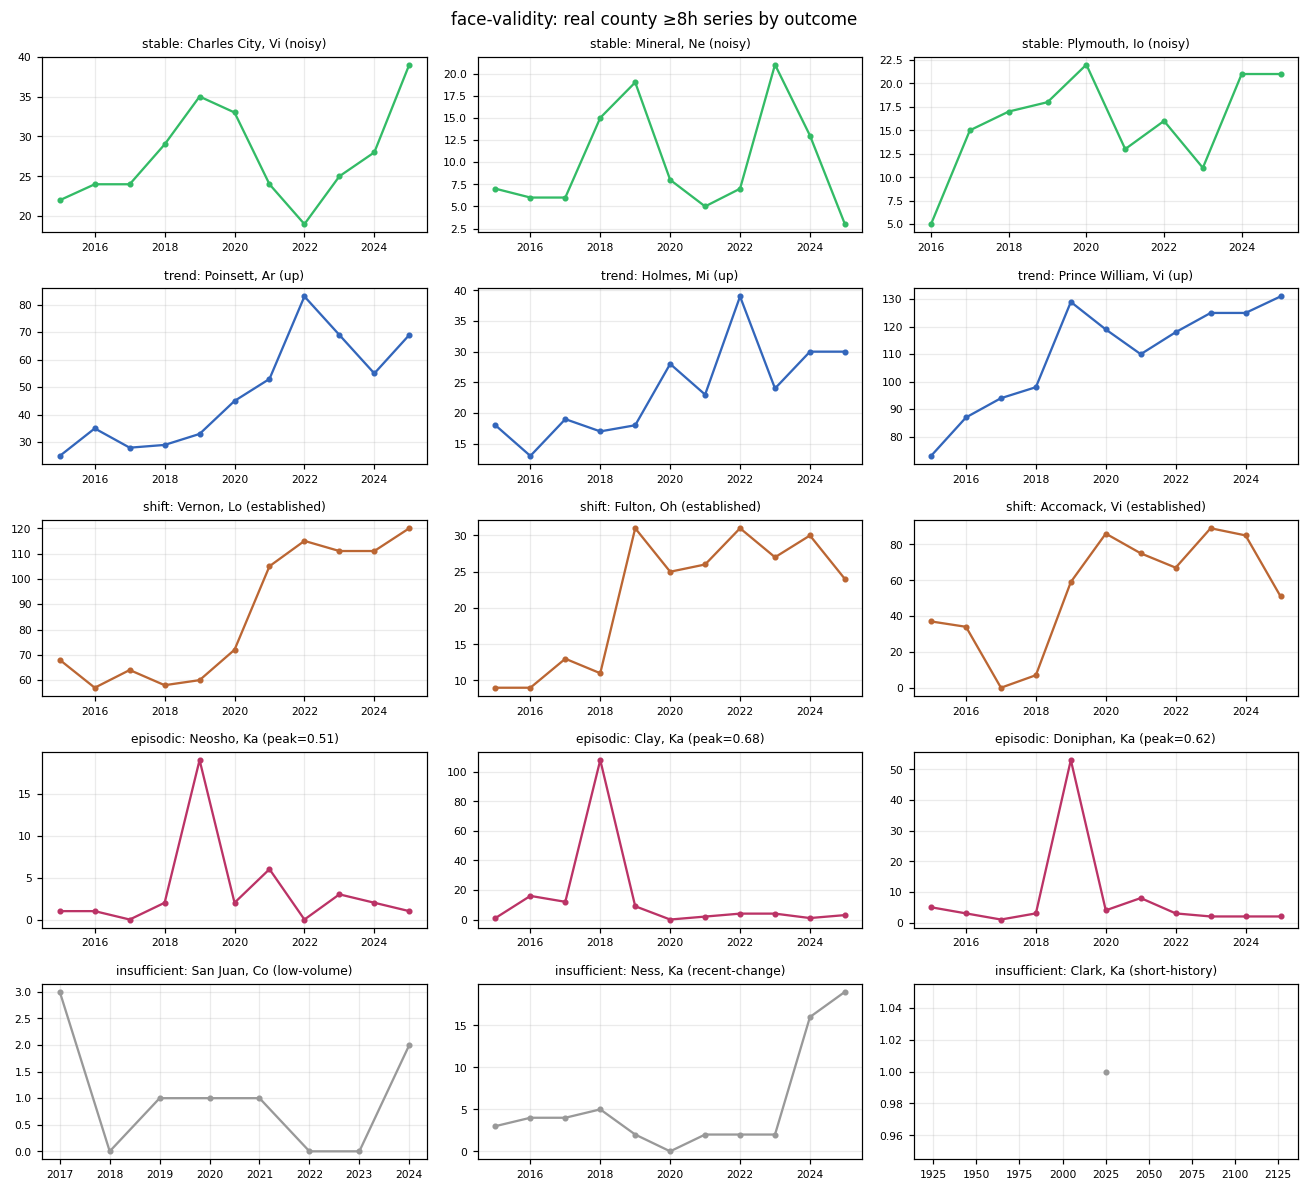

In [6]:
print("spot checks + previously-mislabeled (now honestly insufficient):")
checks = [(48029,"stable"),(12107,"trend"),(40109,"shift"),(53073,"shift"),
          (31031,"insufficient(was trend)"),(47183,"insufficient(was flat)"),(37145,"insufficient(was shift)")]
for fips, exp in checks:
    if fips in res.fips.values:
        r = res[res.fips==fips].iloc[0]; cs=[c for _,c in s8[fips]]
        print(f"  {names[fips][0][:13]:13}{names[fips][1][:5]:5} exp {exp:24}-> {r['regime']:12}{r['sub']:13} {spark(cs)}")

outs = ["stable","trend","shift","episodic","insufficient"]; cols = ["#3b6","#36b","#b63","#b36","#999"]
fig, axes = plt.subplots(5, 3, figsize=(12, 11)); rng = np.random.default_rng(11)
for row, rg in enumerate(outs):
    pool = res[(res.regime==rg)&((res.conf=="high")|(res.regime=="insufficient"))]; pool = pool if len(pool) else res[res.regime==rg]
    pick = pool.sample(min(3,len(pool)), random_state=int(rng.integers(1e6)))
    for col,(_,r) in enumerate(pick.iterrows()):
        ax=axes[row,col]; cs=[c for _,c in s8[r.fips]]; ys=[y for y,_ in s8[r.fips]]
        ax.plot(ys, cs, "-o", ms=3, color=cols[row])
        ax.set_title(f"{rg}: {names[r.fips][0]}, {names[r.fips][1][:2]} ({r['sub']})", fontsize=8); ax.tick_params(labelsize=7)
plt.suptitle("face-validity: real county ≥8h series by outcome", fontsize=11); plt.tight_layout(); plt.show()

## 6. The picture + the artifact

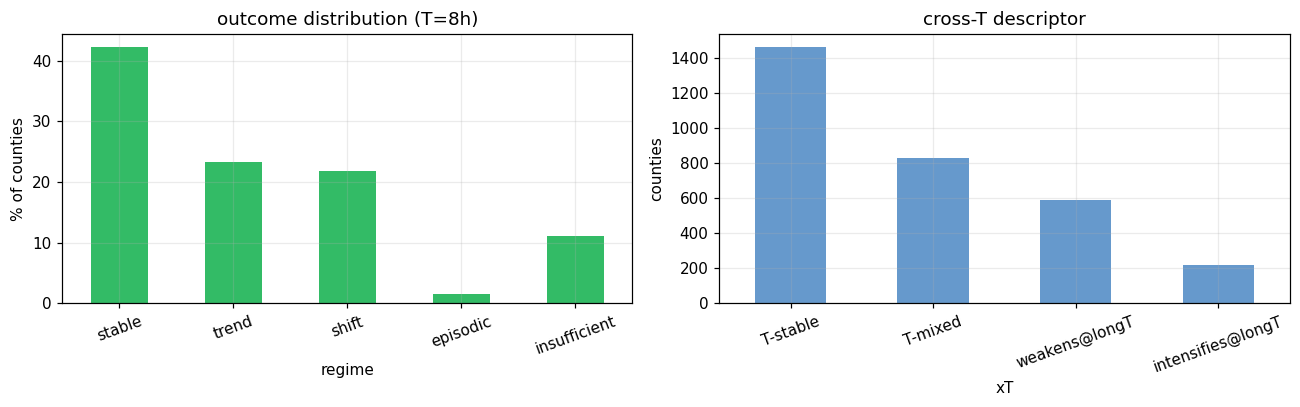

saved -> ../outputs/regime_classification/county_regime_T8.csv  (3090 counties)
columns: ['fips', 'regime', 'sub', 'n_obs', 'first_yr', 'total', 'tstat', 'r_step', 'peak_share', 'cv', 'stab4', 'stabS', 'labels_by_T', 'xT', 'conf']


In [7]:
import os
order = ["stable","trend","shift","episodic","insufficient"]
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
(res['regime'].value_counts(normalize=True)*100).reindex(order).plot.bar(ax=ax[0], color="#3b6", rot=20)
ax[0].set_title("outcome distribution (T=8h)"); ax[0].set_ylabel("% of counties")
res['xT'].value_counts().plot.bar(ax=ax[1], color="#69c", rot=20)
ax[1].set_title("cross-T descriptor"); ax[1].set_ylabel("counties")
plt.tight_layout(); plt.show()

OUT = "../outputs/regime_classification"; os.makedirs(OUT, exist_ok=True)
res.to_csv(f"{OUT}/county_regime_T8.csv", index=False)
print(f"saved -> {OUT}/county_regime_T8.csv  ({len(res)} counties)")
print("columns:", list(res.columns))

## Verdict

```text
 stable 42 · trend 23 · shift 22 · insufficient 11 · episodic 1.5  (% of counties)
 every row carries: regime · sub · confidence · per-T label vector + cross-T descriptor · features.
 the reframe — ABSTAIN, don't force; verified (perfect-fit/volume/reversion/terminal-spike fixed).
 caveats honest: A014 (T) · A015 (insufficient) · A016 (mask).
```

**What this is:** a behavioral identity + honest confidence + the cross-T story (incl. the
chronic-vs-storm `intensifies@longT` read). **Feeds:** Step-5 forecasting + the dashboard. **Not** a
forecast, not a price.